Cargando archivos CSV...
  ✓ inegycei_1990.csv  (186 filas, 30 columnas)
  ✓ inegycei_1991.csv  (186 filas, 30 columnas)
  ✓ inegycei_1992.csv  (186 filas, 30 columnas)
  ✓ inegycei_1993.csv  (186 filas, 30 columnas)
  ✓ inegycei_1994.csv  (186 filas, 30 columnas)
  ✓ inegycei_1995.csv  (186 filas, 30 columnas)
  ✓ inegycei_1996.csv  (186 filas, 30 columnas)
  ✓ inegycei_1997.csv  (186 filas, 30 columnas)
  ✓ inegycei_1998.csv  (187 filas, 30 columnas)
  ✓ inegycei_1999.csv  (186 filas, 30 columnas)
  ✓ inegycei_2000.csv  (186 filas, 30 columnas)
  ✓ inegycei_2001.csv  (186 filas, 30 columnas)
  ✓ inegycei_2002.csv  (186 filas, 30 columnas)
  ✓ inegycei_2003.csv  (186 filas, 30 columnas)
  ✓ inegycei_2004.csv  (186 filas, 30 columnas)
  ✓ inegycei_2005.csv  (186 filas, 30 columnas)
  ✓ inegycei_2006.csv  (186 filas, 31 columnas)
  ✓ inegycei_2007.csv  (186 filas, 30 columnas)
  ✓ inegycei_2008.csv  (186 filas, 30 columnas)
  ✓ inegycei_2009.csv  (186 filas, 30 columnas)
  ✓ inegycei_20

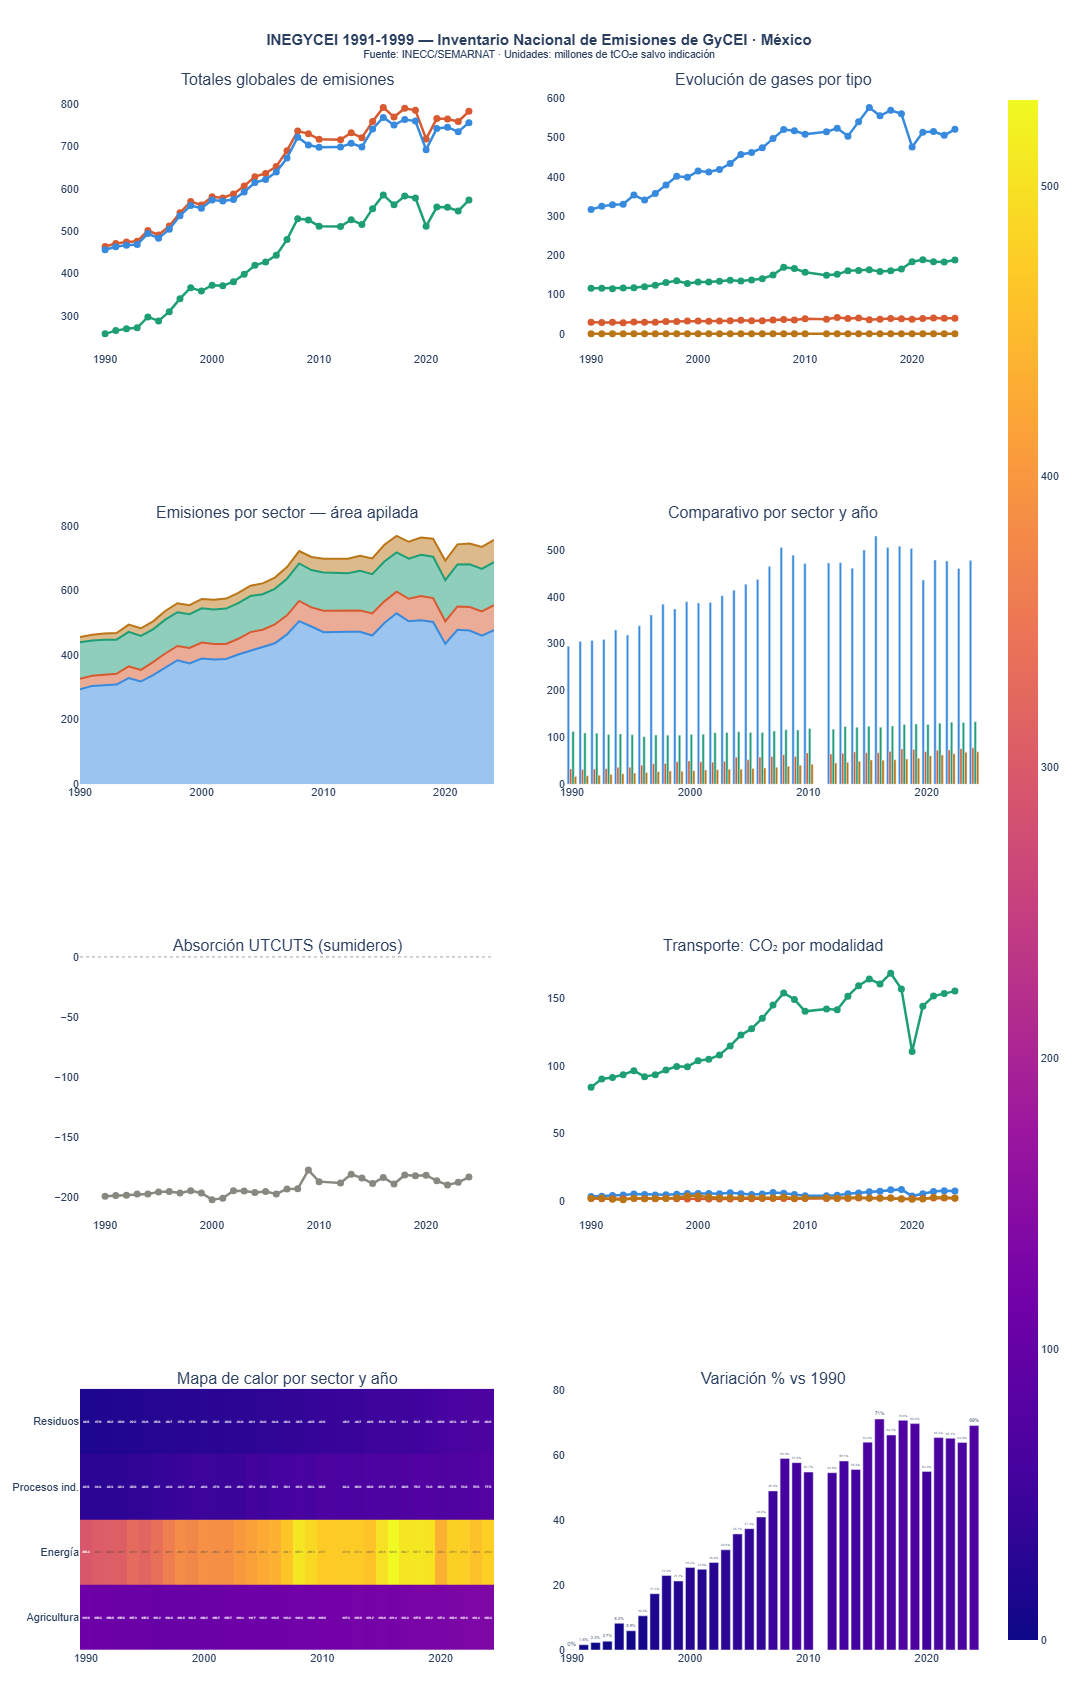


Figuras individuales disponibles:
  fig_totales        Línea — totales globales
  fig_sectores       Área apilada — por sector
  fig_barras_sec     Barras agrupadas — sector x año
  fig_utcuts         Línea — absorción UTCUTS
  fig_gases          Línea — gases por tipo
  fig_trans_time     Línea — transporte por modalidad
  fig_heat           Heatmap — sector x año
  fig_var            Barras — variación % vs año base
  fig_dash           Dashboard completo (4x2)

DataFrames consolidados:
  df_totales   (102, 4)  — totales por año y tipo
  df_sectores  (170, 3) — emisiones por sector y año
  df_gases     (136, 3)  — gases por año
  df_trans     (136, 3)  — transporte por modalidad y año


In [13]:
#Dashboard INEGYCEI 1991-1999 — Series de tiempo multi-año
#Inventario Nacional de Emisiones de Gases y Compuestos de Efecto Invernadero
#Fuente: INEGYCEI / INECC · México

#Dependencias: pandas, plotly
#Instalar:     pip install pandas plotly

#Uso:
#    1. Coloca todos los archivos inegycei_XXXX.csv en la misma carpeta
#    2. Ajusta RUTA_DATOS si los archivos están en otro directorio
#    3. Ejecuta: python dashboard_inegycei_multianio.py
#"""

import os
import glob
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

RUTA_DATOS = "../data/inegycei"          # Carpeta donde están los CSV. Cambia si es necesario.
PATRON     = "inegycei_*.csv"
ANIO_INICIO = 1991
ANIO_FIN    = 2024        # Incluye todos los archivos en ese rango

# ── PALETA ────────────────────────────────────────────────────────────────────

COLOR_SECTOR = {
    "Energía":        "#378ADD",
    "Procesos ind.":  "#D85A30",
    "Agricultura":    "#1D9E75",
    "UTCUTS":         "#888780",
    "Residuos":       "#BA7517",
}
COLOR_GAS = {
    "CO2":  "#378ADD",
    "CH4":  "#1D9E75",
    "N2O":  "#D85A30",
    "SF6":  "#BA7517",
}

# ── 1. CARGA Y CONSOLIDACIÓN ──────────────────────────────────────────────────

def cargar_archivos(ruta: str, patron: str) -> dict[int, pd.DataFrame]:
    """Lee todos los CSV que coincidan con el patrón y devuelve {año: DataFrame}."""
    archivos = sorted(glob.glob(os.path.join(ruta, patron)))
    if not archivos:
        raise FileNotFoundError(
            f"No se encontraron archivos con el patrón '{patron}' en '{ruta}'"
        )
    datos = {}
    for ruta_archivo in archivos:
        nombre = os.path.basename(ruta_archivo)
        try:
            anio = int(nombre.replace("inegycei_", "").replace(".csv", ""))
        except ValueError:
            print(f"  [!] Omitiendo archivo con nombre inesperado: {nombre}")
            continue
        df = pd.read_csv(ruta_archivo)
        df.columns = df.columns.str.strip()
        datos[anio] = df
        print(f"  ✓ {nombre}  ({len(df)} filas, {df.shape[1]} columnas)")
    return datos


print("Cargando archivos CSV...")
datos = cargar_archivos(RUTA_DATOS, PATRON)
anios = sorted(datos.keys())
print(f"\nAños disponibles: {anios}\n")


# ── 2. FUNCIONES DE EXTRACCIÓN ────────────────────────────────────────────────

SECTORES_MAP = {
    "[1]": "Energía",
    "[2]": "Procesos ind.",
    "[3]": "Agricultura",
    "[4]": "UTCUTS",
    "[5]": "Residuos",
}

GASES_COLS = ["CO2", "CH4", "N2O", "SF6"]


def extraer_totales(df: pd.DataFrame) -> dict:
    """Devuelve las tres filas de totales globales."""
    return {
        "brutas":  df.iloc[0]["emisiones_tCO2e"],
        "sin_utcuts": df.iloc[1]["emisiones_tCO2e"],
        "netas":   df.iloc[2]["emisiones_tCO2e"],
    }


def extraer_sectores(df: pd.DataFrame) -> dict:
    """Emisiones tCO2e por sector principal."""
    resultado = {}
    for clave, nombre in SECTORES_MAP.items():
        fila = df[df["categoria_fuente_subfuente_emision"].str.startswith(clave, na=False)]
        if not fila.empty:
            resultado[nombre] = fila.iloc[0]["emisiones_tCO2e"]
    return resultado


def extraer_gases(df: pd.DataFrame) -> dict:
    """Valores de gases en la fila de emisiones brutas."""
    fila = df.iloc[0]
    return {g: fila[g] for g in GASES_COLS if g in df.columns and pd.notna(fila[g])}


def extraer_transporte(df: pd.DataFrame) -> dict:
    """CO2 de subsectores de transporte [1A3x]."""
    mapa = {
        "[1A3a]": "Aviación civil",
        "[1A3b]": "Autotransporte",
        "[1A3c]": "Ferrocarriles",
        "[1A3d]": "Navegación",
    }
    resultado = {}
    for clave, nombre in mapa.items():
        fila = df[df["categoria_fuente_subfuente_emision"].str.startswith(clave, na=False)]
        if not fila.empty and pd.notna(fila.iloc[0]["CO2"]):
            resultado[nombre] = fila.iloc[0]["CO2"]
    return resultado


# ── 3. CONSTRUCCIÓN DE SERIES TEMPORALES ─────────────────────────────────────

registros_totales  = []
registros_sectores = []
registros_gases    = []
registros_trans    = []

for anio, df in datos.items():
    # Totales
    t = extraer_totales(df)
    for tipo, val in t.items():
        registros_totales.append({"año": anio, "tipo": tipo, "valor_M": round(val / 1e6, 2)})

    # Sectores
    s = extraer_sectores(df)
    for sector, val in s.items():
        registros_sectores.append({"año": anio, "sector": sector, "emisiones_M": round(val / 1e6, 2)})

    # Gases
    g = extraer_gases(df)
    for gas, val in g.items():
        registros_gases.append({"año": anio, "gas": gas, "valor_M": round(val / 1e6, 2)})

    # Transporte
    tr = extraer_transporte(df)
    for modal, val in tr.items():
        registros_trans.append({"año": anio, "modalidad": modal, "CO2_M": round(val / 1e6, 2)})


df_totales  = pd.DataFrame(registros_totales)
df_sectores = pd.DataFrame(registros_sectores)
df_gases    = pd.DataFrame(registros_gases)
df_trans    = pd.DataFrame(registros_trans)

# Etiquetas legibles para los totales
etiq_totales = {
    "brutas":     "Brutas (con UTCUTS)",
    "sin_utcuts": "Sin UTCUTS",
    "netas":      "Netas (con absorciones)",
}
df_totales["tipo_label"] = df_totales["tipo"].map(etiq_totales)


# ── 4. FIGURAS INDIVIDUALES ───────────────────────────────────────────────────

# ── 4.1 Línea: totales globales en el tiempo ──────────────────────────────────
fig_totales = px.line(
    df_totales,
    x="año",
    y="valor_M",
    color="tipo_label",
    markers=True,
    title="Emisiones totales de GyCEI — México 1991-1999",
    labels={"valor_M": "Millones tCO₂e", "año": "Año", "tipo_label": ""},
    color_discrete_map={
        "Brutas (con UTCUTS)":     "#D85A30",
        "Sin UTCUTS":              "#378ADD",
        "Netas (con absorciones)": "#1D9E75",
    },
)
fig_totales.update_traces(line_width=2.5, marker_size=7)
fig_totales.update_layout(legend=dict(orientation="h", y=-0.2))

# ── 4.2 Área apilada: sectores sin UTCUTS ────────────────────────────────────
df_sec_plot = df_sectores[df_sectores["sector"] != "UTCUTS"].copy()

fig_sectores = px.area(
    df_sec_plot,
    x="año",
    y="emisiones_M",
    color="sector",
    title="Emisiones por sector (sin UTCUTS) — 1991-1999",
    labels={"emisiones_M": "Millones tCO₂e", "año": "Año", "sector": "Sector"},
    color_discrete_map={k: v for k, v in COLOR_SECTOR.items() if k != "UTCUTS"},
)
fig_sectores.update_layout(legend=dict(orientation="h", y=-0.2))

# ── 4.3 Líneas: UTCUTS (absorción) ───────────────────────────────────────────
df_utcuts = df_sectores[df_sectores["sector"] == "UTCUTS"].copy()

fig_utcuts = px.line(
    df_utcuts,
    x="año",
    y="emisiones_M",
    markers=True,
    title="Absorción por UTCUTS (bosques y sumideros) — 1991-1999",
    labels={"emisiones_M": "Millones tCO₂e", "año": "Año"},
    color_discrete_sequence=["#888780"],
)
fig_utcuts.update_traces(line_width=2.5, marker_size=7)
fig_utcuts.add_hline(y=0, line_dash="dot", line_color="gray", opacity=0.5)

# ── 4.4 Líneas: gases en el tiempo ───────────────────────────────────────────
fig_gases = px.line(
    df_gases,
    x="año",
    y="valor_M",
    color="gas",
    markers=True,
    title="Evolución de gases por tipo — 1991-1999",
    labels={"valor_M": "Millones t", "año": "Año", "gas": "Gas"},
    color_discrete_map=COLOR_GAS,
)
fig_gases.update_traces(line_width=2.5, marker_size=7)
fig_gases.update_layout(legend=dict(orientation="h", y=-0.2))

# ── 4.5 Barras agrupadas: sectores por año ────────────────────────────────────
fig_barras_sec = px.bar(
    df_sec_plot,
    x="año",
    y="emisiones_M",
    color="sector",
    barmode="group",
    title="Comparativo por sector y año — 1991-1999",
    labels={"emisiones_M": "Millones tCO₂e", "año": "Año", "sector": "Sector"},
    color_discrete_map={k: v for k, v in COLOR_SECTOR.items() if k != "UTCUTS"},
)
fig_barras_sec.update_layout(legend=dict(orientation="h", y=-0.2))
fig_barras_sec.update_xaxes(type="category")

# ── 4.6 Líneas: transporte por modalidad ─────────────────────────────────────
fig_trans_time = px.line(
    df_trans,
    x="año",
    y="CO2_M",
    color="modalidad",
    markers=True,
    title="Transporte: CO₂ por modalidad — 1991-1999",
    labels={"CO2_M": "Millones tCO₂", "año": "Año", "modalidad": "Modalidad"},
    color_discrete_sequence=["#378ADD", "#1D9E75", "#D85A30", "#BA7517"],
)
fig_trans_time.update_traces(line_width=2.5, marker_size=7)
fig_trans_time.update_layout(legend=dict(orientation="h", y=-0.2))

# ── 4.7 Heatmap: emisiones tCO2e por sector x año ────────────────────────────
pivot = df_sec_plot.pivot(index="sector", columns="año", values="emisiones_M")

fig_heat = px.imshow(
    pivot,
    color_continuous_scale="Blues",
    title="Mapa de calor: emisiones por sector y año (millones tCO₂e)",
    labels={"color": "Millones tCO₂e", "x": "Año", "y": "Sector"},
    text_auto=".1f",
    aspect="auto",
)
fig_heat.update_coloraxes(colorbar_title="M tCO₂e")

# ── 4.8 Barras: variación % vs 1991 ──────────────────────────────────────────
base = df_totales[df_totales["tipo"] == "brutas"].set_index("año")["valor_M"]
base_1991 = base[anios[0]]
df_var = pd.DataFrame({
    "año": base.index,
    "variacion_pct": ((base - base_1991) / base_1991 * 100).round(1)
}).reset_index(drop=True)

fig_var = px.bar(
    df_var,
    x="año",
    y="variacion_pct",
    color="variacion_pct",
    color_continuous_scale=["#1D9E75", "#f5f5f5", "#D85A30"],
    color_continuous_midpoint=0,
    text="variacion_pct",
    title=f"Variación % de emisiones brutas respecto a {anios[0]}",
    labels={"variacion_pct": "Variación (%)", "año": "Año"},
)
fig_var.update_traces(texttemplate="%{text}%", textposition="outside")
fig_var.update_layout(coloraxis_showscale=False)
fig_var.update_xaxes(type="category")
fig_var.add_hline(y=0, line_dash="dot", line_color="gray", opacity=0.5)


# ── 5. DASHBOARD COMBINADO ────────────────────────────────────────────────────

fig_dash = make_subplots(
    rows=4, cols=2,
    subplot_titles=(
        "Totales globales de emisiones",
        "Evolución de gases por tipo",
        "Emisiones por sector — área apilada",
        "Comparativo por sector y año",
        "Absorción UTCUTS (sumideros)",
        "Transporte: CO₂ por modalidad",
        "Mapa de calor por sector y año",
        f"Variación % vs {anios[0]}",
    ),
    vertical_spacing=0.11,
    horizontal_spacing=0.08,
)

# Fila 1
for tr in fig_totales.data:
    fig_dash.add_trace(tr, row=1, col=1)
for tr in fig_gases.data:
    fig_dash.add_trace(tr, row=1, col=2)

# Fila 2
for tr in fig_sectores.data:
    fig_dash.add_trace(tr, row=2, col=1)
for tr in fig_barras_sec.data:
    fig_dash.add_trace(tr, row=2, col=2)

# Fila 3
for tr in fig_utcuts.data:
    fig_dash.add_trace(tr, row=3, col=1)
for tr in fig_trans_time.data:
    fig_dash.add_trace(tr, row=3, col=2)

# Fila 4 — heatmap y variación
for tr in fig_heat.data:
    fig_dash.add_trace(tr, row=4, col=1)
for tr in fig_var.data:
    fig_dash.add_trace(tr, row=4, col=2)

fig_dash.update_layout(
    title=dict(
        text=(
            "<b>INEGYCEI 1991-1999 — Inventario Nacional de Emisiones de GyCEI · México</b><br>"
            "<sup>Fuente: INECC/SEMARNAT · Unidades: millones de tCO₂e salvo indicación</sup>"
        ),
        font=dict(size=15),
        x=0.5,
        xanchor="center",
    ),
    height=1700,
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial, sans-serif", size=11),
    margin=dict(t=90, b=50, l=70, r=40),
)

# Línea de referencia y=0 en subplot de UTCUTS
fig_dash.add_hline(y=0, line_dash="dot", line_color="gray", opacity=0.4, row=3, col=1)


# ── 6. SALIDA ─────────────────────────────────────────────────────────────────

print("Abriendo dashboard en el navegador...")
fig_dash.show()

# Para exportar como HTML interactivo (sin dependencias extra):
# fig_dash.write_html("dashboard_inegycei_multianio.html")

# Para exportar como imagen (requiere:  pip install kaleido):
# fig_dash.write_image("dashboard_inegycei_multianio.png", width=1400, height=1700, scale=2)

print("\nFiguras individuales disponibles:")
figuras = {
    "fig_totales":    "Línea — totales globales",
    "fig_sectores":   "Área apilada — por sector",
    "fig_barras_sec": "Barras agrupadas — sector x año",
    "fig_utcuts":     "Línea — absorción UTCUTS",
    "fig_gases":      "Línea — gases por tipo",
    "fig_trans_time": "Línea — transporte por modalidad",
    "fig_heat":       "Heatmap — sector x año",
    "fig_var":        "Barras — variación % vs año base",
    "fig_dash":       "Dashboard completo (4x2)",
}
for var, desc in figuras.items():
    print(f"  {var:<18} {desc}")

print("\nDataFrames consolidados:")
print(f"  df_totales   {df_totales.shape}  — totales por año y tipo")
print(f"  df_sectores  {df_sectores.shape} — emisiones por sector y año")
print(f"  df_gases     {df_gases.shape}  — gases por año")
print(f"  df_trans     {df_trans.shape}  — transporte por modalidad y año")

